# DBSCAN Demo

 - Course Title: Problem Solving Using Pattern Recognition
 - Lecturer: Zhengqing Hu
 - Copyright 2026 National University of Singapore
 - Jupyter Notebook v 7.1.2
 - Python 3.12.2 (!python --version)
 - scikit-learn 1.4.2 (!pip show scikit-learn)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('diabetes_imputed.csv')
cols = list(df) 
df.shape

(768, 9)

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
df_std = StandardScaler().fit_transform(df) 
#df_std = MinMaxScaler().fit_transform(df)

# DBSCAN

Min Points: 18


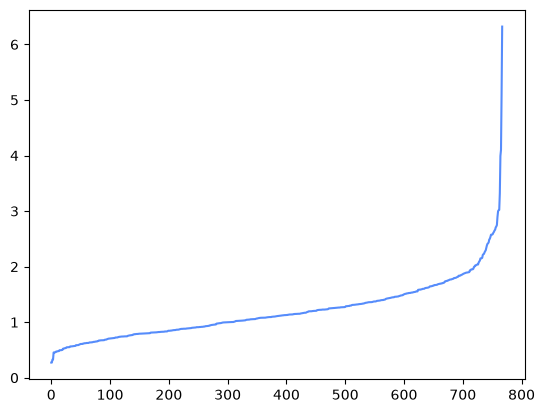

In [6]:
from sklearn.cluster import DBSCAN
# To estimate the minpts and epsilon, read this article
# https://medium.com/@tarammullin/dbscan-parameter-estimation-ff8330e3a3bd

# Obtaining the Min pts using Cols X 2
minpoints = 2 * df_std.shape[1]

# Finding the epsilon using NN with minpoints
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=minpoints)
neighbors_fit = neighbors.fit(df_std)
distances, indices = neighbors_fit.kneighbors(df_std)
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)
print('Min Points:', minpoints)

In [7]:
#examine the scree plot, locate an elbow value on the y-axis.
epsilon = 2.0
#minpoints =15

In [8]:
dbsc = DBSCAN(eps = epsilon, min_samples = minpoints).fit(df_std)

labels = dbsc.labels_ #cluster labels for each datapoint
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Minpts=",minpoints,'   Epsilon=',epsilon)
print('Number of clusters: %d' % n_clusters_)
print('Number of noise points: %d' % n_noise_)

df['cluster_db'] = labels.tolist() # add the cluster label as a col to original data
ccount = df.groupby('cluster_db')['cluster_db'].count()
cluster_table = df.groupby(['cluster_db']).agg('mean')
cluster_table['count'] = ccount
display(np.round(cluster_table,decimals=3))
#cluster_table.to_csv('clusters.csv')

Minpts= 18    Epsilon= 2.0
Number of clusters: 2
Number of noise points: 116


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,count
cluster_db,,,,,,,,,,
-1,4.871,143.207,78.491,32.655,245.500,35.628,0.800,41.302,0.586,116
0,3.228,108.217,70.122,26.717,111.053,30.526,0.391,30.106,0.000,452
1,4.645,139.525,73.732,32.106,189.951,34.809,0.465,35.650,1.000,200


## Use an automated way to detect elbow

Estimated epsilon (ε) using automated elbow detection: 2.1917


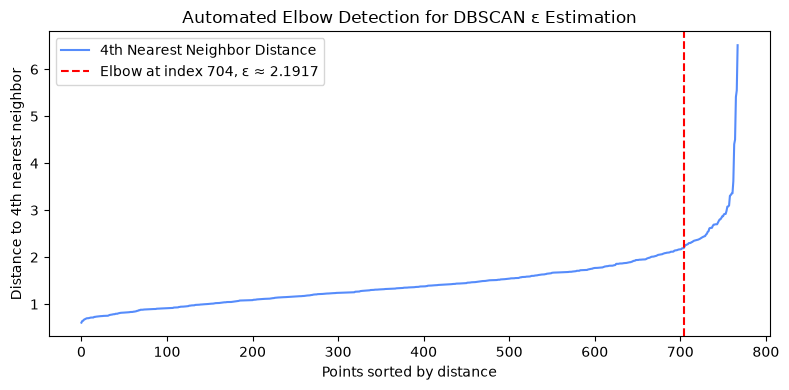

In [9]:
X = df_std.copy()

# Compute the distances to the minpoints nearest neighbor
neighbors = NearestNeighbors(n_neighbors=minpoints)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort the distances to the 4th nearest neighbor
k_distances = np.sort(distances[:, 3])

# Automated elbow detection using curvature method
def find_elbow_point(distances):
    n_points = len(distances)
    all_coords = np.vstack((range(n_points), distances)).T
    first_point = all_coords[0]
    last_point = all_coords[-1]

    line_vec = last_point - first_point
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    vec_from_first = all_coords - first_point
    scalar_product = np.dot(vec_from_first, line_vec_norm)
    proj = np.outer(scalar_product, line_vec_norm)
    vec_to_line = vec_from_first - proj
    dist_to_line = np.linalg.norm(vec_to_line, axis=1)

    elbow_index = np.argmax(dist_to_line)
    return elbow_index, distances[elbow_index]

elbow_index, epsilon = find_elbow_point(k_distances)

# Plot the k-distance graph with the detected elbow
plt.figure(figsize=(8, 4))
plt.plot(k_distances, label='4th Nearest Neighbor Distance')
plt.axvline(x=elbow_index, color='r', linestyle='--', label=f'Elbow at index {elbow_index}, ε ≈ {epsilon:.4f}')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to 4th nearest neighbor')
plt.title('Automated Elbow Detection for DBSCAN ε Estimation')
plt.legend()
plt.tight_layout()
plt.savefig("automated_elbow_detection.png")

# Output the estimated epsilon value
print(f"Estimated epsilon (ε) using automated elbow detection: {epsilon:.4f}")


In [10]:
dbsc = DBSCAN(eps = epsilon, min_samples = minpoints).fit(df_std)

labels = dbsc.labels_ #cluster labels for each datapoint
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Minpts=",minpoints,'   Epsilon=',epsilon)
print('Number of clusters: %d' % n_clusters_)
print('Number of noise points: %d' % n_noise_)

df['cluster_db'] = labels.tolist() # add the cluster label as a col to original data
ccount = df.groupby('cluster_db')['cluster_db'].count()
cluster_table = df.groupby(['cluster_db']).agg('mean')
cluster_table['count'] = ccount
display(np.round(cluster_table,decimals=3))
#cluster_table.to_csv('clusters.csv')

Minpts= 18    Epsilon= 2.1917207363956366
Number of clusters: 1
Number of noise points: 70


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,count
cluster_db,,,,,,,,,,
-1,4.157,146.157,78.900,34.617,282.757,37.407,0.854,40.300,0.543,70
0,3.814,119.198,71.667,28.456,138.784,31.911,0.434,32.533,0.330,698
